In [1]:
import os
os.environ['PATH'] = '/home/irman/Gelochip/.venv/bin:' + os.environ.get('PATH', '')
import sys, os
os.environ.setdefault('PDK_ROOT', os.path.expanduser('~/pdks'))
sys.path.insert(0, '/home/irman/Gelochip/src/gelochip')

import klayout.db as kdb
import klayout.lay as klay
from IPython.display import Image, display

def show_gds(gds_path, out_png=None, width=1600, height=900):
    gds_abs = os.path.abspath(gds_path)
    if not os.path.exists(gds_abs):
        print(f'GDS not found: {gds_abs}'); return
    out_png = out_png or gds_abs.replace('.gds', '_preview.png')
    lv = klay.LayoutView()
    lv.load_layout(gds_abs, True)
    lv.max_hier(); lv.zoom_fit()
    lv.save_image(out_png, width, height)
    display(Image(out_png))




/home/irman/Gelochip/src/gelochip/glayout/pdk/mappedpdk.py:511: SyntaxWarning: invalid escape sequence '\['
  new_path = temp_dir / "magic_commands.tcl"
/home/irman/Gelochip/src/gelochip/glayout/pdk/mappedpdk.py:512: SyntaxWarning: invalid escape sequence '\['
  with open(str(new_path.resolve()), 'w') as f:


2026-05-18 19:31:23.238 | WARNING  | gdsfactory.pdk:get_active_pdk:733 - No active PDK. Activating generic PDK.



2026-05-18 19:31:23.573 | INFO     | gdsfactory.technology.layer_views:__init__:790 - Importing LayerViews from YAML file: '/home/irman/Gelochip/.venv/lib/python3.13/site-packages/gdsfactory/generic_tech/layer_views.yaml'.


2026-05-18 19:31:23.574 | INFO     | gdsfactory.pdk:activate:337 - 'generic' PDK is now active


2026-05-18 19:31:23.581 | INFO     | gdsfactory.pdk:activate:337 - 'gf180' PDK is now active


...

using default pdk_root
Defaulting to stale magic_commands.tcl


2026-05-18 19:31:26.876 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/tmp/tmpduxi0sgo/CMIRROR.gds'



Magic 8.3 revision 644 - Compiled on Sun May 17 10:32:25 PM WIB 2026.
Starting magic under Tcl interpreter
Using the terminal as the console.
Using NULL graphics device.
Processing system .magicrc file
Switching to WIRING tool.
Switching to NETLIST tool.
Switching to PICK tool.
Switching to BOX tool.
Sourcing design .magicrc for technology gf180mcuD ...
10 Magic internal units = 1 Lambda
Input style import: scaleFactor=10, multiplier=2
The following types are not handled by extraction and will be treated as non-electrical types:
    obsactive mvobsactive filldiff fillpoly m1hole obsm1 fillm1 obsv1 m2hole obsm2 fillm2 obsv2 m3hole obsm3 fillm3 m4hole obsm4 fillm4 m5hole obsm5 fillm5 glass fillblock lvstext obscomment 
Scaled tech values by 10 / 1 to match internal grid scaling
Loading gf180mcuD Device Generator Menu ...
Loading "/tmp/tmpp2d89sf7/magic_commands.tcl" from command line.
Library written using GDS-II Release 6.0
Library name: library
Reading "CMIRROR".
[INFO]: Loading CMIRR

2026-05-18 19:31:27.140 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to 'cm.gds'



Magic 8.3 revision 644 - Compiled on Sun May 17 10:32:25 PM WIB 2026.
Starting magic under Tcl interpreter
Using the terminal as the console.
Using NULL graphics device.
Processing system .magicrc file
Switching to WIRING tool.
Switching to NETLIST tool.
Switching to PICK tool.
Switching to BOX tool.
Sourcing design .magicrc for technology gf180mcuD ...
10 Magic internal units = 1 Lambda
Input style import: scaleFactor=10, multiplier=2
The following types are not handled by extraction and will be treated as non-electrical types:
    obsactive mvobsactive filldiff fillpoly m1hole obsm1 fillm1 obsv1 m2hole obsm2 fillm2 obsv2 m3hole obsm3 fillm3 m4hole obsm4 fillm4 m5hole obsm5 fillm5 glass fillblock lvstext obscomment 
Scaled tech values by 10 / 1 to match internal grid scaling
Loading gf180mcuD Device Generator Menu ...
Using technology "gf180mcuD", version 1.0.493-0-g0fe599b
Library written using GDS-II Release 6.0
Library name: library
Reading "CMIRROR".
Extracting CMIRROR into CMIRR

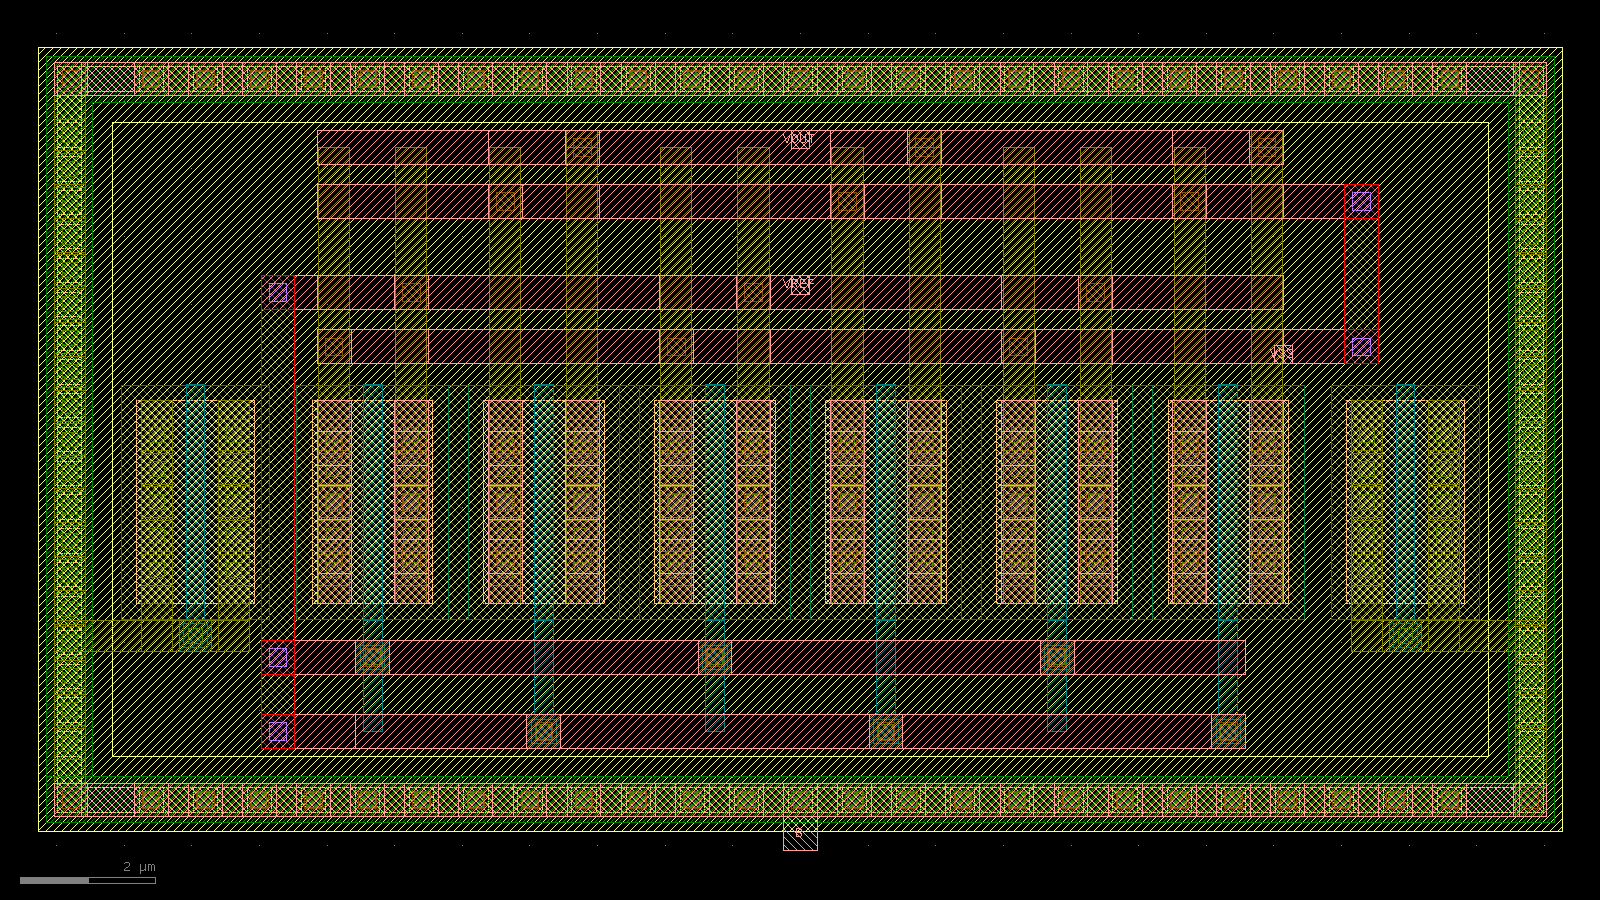

In [2]:
import sys
try:
    cm_mod = sys.modules['glayout.cells.elementary.current_mirror.current_mirror']
    if not hasattr(cm_mod, 'orig_cmn'):
        orig_cmn = cm_mod.current_mirror_netlist
        cm_mod.orig_cmn = orig_cmn
        def patched_cmn(pdk, width, length, multipliers, fingers=1, **kwargs):
            netlist = orig_cmn(pdk, width=width, length=length, multipliers=multipliers, fingers=fingers, **kwargs)
            if 'B' in netlist.nodes:
                idx = netlist.nodes.index('B')
                netlist.nodes[idx] = 'VB'
            if 'VOUT' in netlist.nodes:
                idx = netlist.nodes.index('VOUT')
                netlist.nodes[idx] = 'VCOPY'
            return netlist
        cm_mod.current_mirror_netlist = patched_cmn
        for modname, mod in list(sys.modules.items()):
            if hasattr(mod, 'current_mirror_netlist'):
                setattr(mod, 'current_mirror_netlist', patched_cmn)
except Exception as e:
    pass

from glayout.placement.two_transistor_interdigitized import two_nfet_interdigitized, two_pfet_interdigitized, two_tran_interdigitized_netlist
from glayout.pdk.mappedpdk import MappedPDK
from glayout.routing.c_route import c_route
from glayout.routing.L_route import L_route
from glayout.routing.straight_route import straight_route
from glayout.spice.netlist import Netlist
from glayout.primitives.fet import nmos, pmos
from glayout.primitives.guardring import tapring
from glayout.util.port_utils import add_ports_perimeter,rename_ports_by_orientation
from gdsfactory.component import Component
from gdsfactory.cell import cell
from glayout.util.comp_utils import evaluate_bbox, prec_center, prec_ref_center, align_comp_to_port
from typing import Optional, Union 
from glayout.primitives.via_gen import via_stack
from gdsfactory.components import text_freetype, rectangle
from glayout.pdk.gf180_mapped import gf180_mapped_pdk
try:
    from glayout.verification.evaluator_wrapper import run_evaluation
except ImportError:
    print("Warning: evaluator_wrapper not found. Evaluation will be skipped.")
    run_evaluation = None


def add_cm_labels(cm_in: Component,
                pdk: MappedPDK 
                ) -> Component:
	
    cm_in.unlock()
    met2_pin = (68,16)
    met2_label = (68,5)

    # list that will contain all port/comp info
    move_info = list()
    # create labels and append to info list
    # vss
    vsslabel = rectangle(layer=pdk.get_glayer("met2_pin"),size=(0.27,0.27),centered=True).copy()
    vsslabel.add_label(text="VSS",layer=pdk.get_glayer("met2_label"))
    move_info.append((vsslabel,cm_in.ports["fet_A_source_E"],None))
    
    # vref
    vreflabel = rectangle(layer=pdk.get_glayer("met2_pin"),size=(0.27,0.27),centered=True).copy()
    vreflabel.add_label(text="VREF",layer=pdk.get_glayer("met2_label"))
    move_info.append((vreflabel,cm_in.ports["fet_A_drain_N"],None))
    
    # vcopy
    vcopylabel = rectangle(layer=pdk.get_glayer("met2_pin"),size=(0.27,0.27),centered=True).copy()
    vcopylabel.add_label(text="VOUT",layer=pdk.get_glayer("met2_label"))
    move_info.append((vcopylabel,cm_in.ports["fet_B_drain_N"],None))
    
    # VB
    vblabel = rectangle(layer=pdk.get_glayer("met2_pin"),size=(0.5,0.5),centered=True).copy()
    vblabel.add_label(text="B",layer=pdk.get_glayer("met2_label"))
    move_info.append((vblabel,cm_in.ports["welltie_S_top_met_S"], None))
    
    # move everything to position
    for comp, prt, alignment in move_info:
        alignment = ('c','b') if alignment is None else alignment
        compref = align_comp_to_port(comp, prt, alignment=alignment)
        cm_in.add(compref)
    return cm_in.flatten() 
					
def current_mirror_interdigitized_netlist(
    pdk: MappedPDK,
    width: float,
    length: float,
    fingers: int,
    multipliers: int, 
    with_dummy: bool = True,
    n_or_p_fet: Optional[str] = 'nfet',
    subckt_only: Optional[bool] = False
) -> Netlist:
    """
    Current mirror netlist built from a two-transistor interdigitized primitive
    """

    current_mirror_netlist = Netlist(circuit_name="CMIRROR", nodes=["VREF", "VOUT", "VSS", "B"])

    current_mirror_netlist.connect_netlist(
        two_tran_interdigitized_netlist(
            pdk=pdk,
            width=width,
            length=length,
            fingers=fingers,
            multipliers=multipliers,
            with_dummy=with_dummy,
            n_or_p_fet=n_or_p_fet,
        ),
        [
            ("VDD1", "VREF"),   # reference drain
            ("VG1",  "VREF"),   # reference gate (diode-connected)
            ("VDD2", "VOUT"),   # mirror drain
            ("VG2",  "VREF"),   # mirror gate
            ("VSS1", "VSS"),    # shared source
            ("VSS2", "VSS"),
            ("VB",   "B"),      # bulk
        ],
    )

    return current_mirror_netlist


# Backward-compatible export used by __init__.py and downstream imports.
current_mirror_netlist = current_mirror_interdigitized_netlist

def current_mirror(
    pdk: MappedPDK, 
    numcols: int = 3,
    device: str = 'nfet',
    with_dummy: Optional[bool] = True,
    with_substrate_tap: Optional[bool] = False,
    with_tie: Optional[bool] = True,
    tie_layers: tuple[str,str]=("met2","met1"),
    **kwargs
) -> Component:
    """An instantiable current mirror that returns a Component object. The current mirror is a two transistor interdigitized structure with a shorted source and gate. It can be instantiated with either nmos or pmos devices. It can also be instantiated with a dummy device, a substrate tap, and a tie layer, and is centered at the origin. Transistor A acts as the reference and Transistor B acts as the mirror fet

    Args:
        pdk (MappedPDK): the process design kit to use
        numcols (int): number of columns of the interdigitized fets
        device (str): nfet or pfet (can only interdigitize one at a time with this option)
        with_dummy (bool): True places dummies on either side of the interdigitized fets
        with_substrate_tap (bool): boolean to decide whether to place a substrate tapring
        with_tie (bool): boolean to decide whether to place a tapring for tielayer
        tie_layers (tuple[str,str], optional): the layers to use for the tie. Defaults to ("met2","met1").
        **kwargs: The keyword arguments are passed to the two_nfet_interdigitized or two_pfet_interdigitized functions and need to be valid arguments that can be accepted by the multiplier function

    Returns:
        Component: a current mirror component object
    """
    top_level = Component("current mirror")
    if device in ['nmos', 'nfet']:
        interdigitized_fets = two_nfet_interdigitized(
            pdk, 
            numcols=numcols, 
            dummy=with_dummy, 
            with_substrate_tap=False, 
            with_tie=False, 
            **kwargs
        )
    elif device in ['pmos', 'pfet']:
        interdigitized_fets = two_pfet_interdigitized(
            pdk, 
            numcols=numcols, 
            dummy=with_dummy, 
            with_substrate_tap=False, 
            with_tie=False, 
            **kwargs
        )
    top_level.add_ports(interdigitized_fets.get_ports_list(), prefix="fet_")
    maxmet_sep = pdk.util_max_metal_seperation()
    # short source of the fets
    source_short = interdigitized_fets << c_route(pdk, interdigitized_fets.ports['A_source_E'], interdigitized_fets.ports['B_source_E'], extension=3*maxmet_sep, viaoffset=False)
    # short gates of the fets
    gate_short = interdigitized_fets << c_route(pdk, interdigitized_fets.ports['A_gate_W'], interdigitized_fets.ports['B_gate_W'], extension=3*maxmet_sep, viaoffset=False)
    # short gate and drain of one of the reference 
    interdigitized_fets << L_route(pdk, interdigitized_fets.ports['A_drain_W'], gate_short.ports['con_N'], viaoffset=False, fullbottom=False)
    
    top_level << interdigitized_fets
    if with_tie:
        if device in ['nmos','nfet']:
            tap_layer = "p+s/d"
        if device in ['pmos','pfet']:
            tap_layer = "n+s/d"
        tap_sep = max(
            float(pdk.util_max_metal_seperation()),
            float(pdk.get_grule("active_diff", "active_tap")["min_separation"]),
        )
        tap_sep += float(pdk.get_grule(tap_layer, "active_tap")["min_enclosure"])
        tap_encloses = (
        2 * (tap_sep + interdigitized_fets.xmax),
        2 * (tap_sep + interdigitized_fets.ymax),
        )
        tie_ref = top_level << tapring(pdk, enclosed_rectangle = tap_encloses, sdlayer = tap_layer, horizontal_glayer = tie_layers[0], vertical_glayer = tie_layers[1])
        top_level.add_ports(tie_ref.get_ports_list(), prefix="welltie_")
        try:
            top_level << straight_route(pdk, top_level.ports[f"fet_B_{numcols - 1}_dummy_R_gsdcon_top_met_E"],top_level.ports["welltie_E_top_met_E"],glayer2="met1")
            top_level << straight_route(pdk, top_level.ports["fet_A_0_dummy_L_gsdcon_top_met_W"],top_level.ports["welltie_W_top_met_W"],glayer2="met1")
        except KeyError:
            pass
        try:
            end_col = numcols - 1
            port1 = f'B_{end_col}_dummy_R_gdscon_top_met_E'
            top_level << straight_route(pdk, top_level.ports[port1], top_level.ports["welltie_E_top_met_E"], glayer2="met1")
        except KeyError:
            pass
    
    # add a pwell 
    if device in ['nmos','nfet']:
        top_level.add_padding(layers = (pdk.get_glayer("pwell"),), default = pdk.get_grule("pwell", "active_tap")["min_enclosure"], )
        top_level = add_ports_perimeter(top_level, layer = pdk.get_glayer("pwell"), prefix="well_")
    if device in ['pmos','pfet']:
        top_level.add_padding(layers = (pdk.get_glayer("nwell"),), default = pdk.get_grule("nwell", "active_tap")["min_enclosure"], )
        top_level = add_ports_perimeter(top_level, layer = pdk.get_glayer("nwell"), prefix="well_")

 
    # add the substrate tap if specified
    if with_substrate_tap:
        subtap_sep = pdk.get_grule("dnwell", "active_tap")["min_separation"]
        subtap_enclosure = (
            2.5 * (subtap_sep + interdigitized_fets.xmax),
            2.5 * (subtap_sep + interdigitized_fets.ymax),
        )
        subtap_ring = top_level << tapring(pdk, enclosed_rectangle = subtap_enclosure, sdlayer = "p+s/d", horizontal_glayer = "met2", vertical_glayer = "met1")
        top_level.add_ports(subtap_ring.get_ports_list(), prefix="substrate_tap_")
  
    top_level.add_ports(source_short.get_ports_list(), prefix='purposegndports')

    top_level.info["netlist"] = current_mirror_interdigitized_netlist(
        pdk=pdk,
        width=kwargs.get("width", 3),
        length=kwargs.get("length", 0.15),
        fingers=kwargs.get("fingers",1),
        multipliers=numcols,
        with_dummy=with_dummy,
        n_or_p_fet=device,
        subckt_only=True
    )
 
    return top_level

if __name__=="__main__":
    cm = add_cm_labels(current_mirror(gf180_mapped_pdk, device='pfet'),gf180_mapped_pdk)
    pass # cm.show()
    cm.name = "CMIRROR"
    try:
        drc_result = gf180_mapped_pdk.drc_magic(cm, cm.name)
        print('DRC:', drc_result)
    except Exception as e:
        print(f'DRC skipped: {e}')
    try:
        lvs_result = gf180_mapped_pdk.lvs_netgen(cm, cm.name)
        print('LVS:', lvs_result['result_str'])
    except Exception as e:
        print(f'LVS skipped: {e}')
    current_mirror_gds = cm.write_gds("cm.gds")
    if run_evaluation is not None:
        pass # res = run_evaluation("cm.gds", cm.name, cm)
    else:
        print("Skipping evaluation because evaluator_wrapper was not found.")


# Show the generated GDS
show_gds("cm.gds")




In [3]:
try:
    from glayout.verification.evaluator_wrapper import run_evaluation
except ImportError:
    print("Warning: evaluator_wrapper not found. Evaluation will be skipped.")
    run_evaluation = None

if run_evaluation is not None:
    result = run_evaluation("cm.gds", cm.name, cm)
    print(result)


--- Starting Comprehensive Evaluation for CMIRROR ---
Cleaning up intermediate files for component 'CMIRROR'...
  - Deleted: CMIRROR.res.ext
  - Deleted directory: CMIRROR_drc_out
  - Deleted directory: CMIRROR_lvs_out
  - Deleted: CMIRROR.nodes
Running verification checks (DRC, LVS)...
using default pdk_root
Defaulting to stale magic_commands.tcl


2026-05-18 19:31:27.494 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/tmp/tmpxxg_q4h0/CMIRROR.gds'



Magic 8.3 revision 644 - Compiled on Sun May 17 10:32:25 PM WIB 2026.
Starting magic under Tcl interpreter
Using the terminal as the console.
Using NULL graphics device.
Processing system .magicrc file
Switching to WIRING tool.
Switching to NETLIST tool.
Switching to PICK tool.
Switching to BOX tool.
Sourcing design .magicrc for technology gf180mcuD ...
10 Magic internal units = 1 Lambda
Input style import: scaleFactor=10, multiplier=2
The following types are not handled by extraction and will be treated as non-electrical types:
    obsactive mvobsactive filldiff fillpoly m1hole obsm1 fillm1 obsv1 m2hole obsm2 fillm2 obsv2 m3hole obsm3 fillm3 m4hole obsm4 fillm4 m5hole obsm5 fillm5 glass fillblock lvstext obscomment 
Scaled tech values by 10 / 1 to match internal grid scaling
Loading gf180mcuD Device Generator Menu ...
Loading "/tmp/tmpbjr8mgrn/magic_commands.tcl" from command line.
Library written using GDS-II Release 6.0
Library name: library
Reading "CMIRROR".
[INFO]: Loading CMIRR


Magic 8.3 revision 644 - Compiled on Sun May 17 10:32:25 PM WIB 2026.
Starting magic under Tcl interpreter
Using the terminal as the console.
Using NULL graphics device.
Processing system .magicrc file
Switching to WIRING tool.
Switching to NETLIST tool.
Switching to PICK tool.
Switching to BOX tool.
Sourcing design .magicrc for technology gf180mcuD ...
10 Magic internal units = 1 Lambda
Input style import: scaleFactor=10, multiplier=2
The following types are not handled by extraction and will be treated as non-electrical types:
    obsactive mvobsactive filldiff fillpoly m1hole obsm1 fillm1 obsv1 m2hole obsm2 fillm2 obsv2 m3hole obsm3 fillm3 m4hole obsm4 fillm4 m5hole obsm5 fillm5 glass fillblock lvstext obscomment 
Scaled tech values by 10 / 1 to match internal grid scaling
Loading gf180mcuD Device Generator Menu ...
Using technology "gf180mcuD", version 1.0.493-0-g0fe599b
Library written using GDS-II Release 6.0
Library name: library
Reading "CMIRROR".
Extracting CMIRROR into CMIRR

--- Evaluation complete. Results saved to CMIRROR_2.json ---
{'component_name': 'CMIRROR', 'timestamp': '2026-05-18T19:31:28.427966', 'drc_lvs_fail': False, 'drc': {'status': 'pass', 'is_pass': True, 'report_path': '/home/irman/Gelochip/notebooks/datasets/current_mirror/CMIRROR_drc_out/drc/CMIRROR/CMIRROR.rpt', 'summary': {'is_pass': True, 'total_errors': 0, 'error_details': []}}, 'lvs': {'status': 'pass', 'is_pass': True, 'report_path': '/home/irman/Gelochip/notebooks/datasets/current_mirror/CMIRROR_lvs_out/lvs/CMIRROR/CMIRROR_lvs.rpt', 'summary': {'is_pass': True, 'conclusion': 'LVS Pass: Netlists match.', 'total_mismatches': 0, 'mismatch_details': {'nets': '4                          |Number of nets: 4', 'devices': '3                       |Number of devices: 3', 'unmatched_nets_parsed': [], 'unmatched_instances_parsed': []}}}, 'pex': {'status': 'PEX Complete', 'total_resistance_ohms': 4293.273582000025, 'total_capacitance_farads': 9.799548000000047e-14}, 'geometric': {'raw_area_um2

In [4]:
# ── SPICE Simulation with gf180 PDK models ─────────────────────────────────
import subprocess, os, re, tempfile

_GF180_MODELS = '/home/irman/Gelochip/src/gelochip/glayout/spice/gf180_typical.spice'

class _StringNetlist:
    def __init__(self, spice_str):
        import re as _re
        self._spice = spice_str
        # Use the LAST .subckt definition (top-level circuit)
        matches = list(_re.finditer(r'\.subckt\s+(\w+)\s+(.*)', spice_str, _re.IGNORECASE))
        if matches:
            m = matches[-1]
            self.circuit_name = m.group(1)
            # Filter out parameter-style tokens (containing =)
            self.nodes = [n for n in m.group(2).split() if '=' not in n]
        else:
            self.circuit_name = 'UNKNOWN'; self.nodes = []
    def generate_netlist(self): return self._spice

def _get_netlist(comp):
    if not hasattr(comp, 'info'): return None
    nl = comp.info.get('netlist_obj')
    if nl is not None and hasattr(nl, 'generate_netlist'): return nl
    nl = comp.info.get('netlist')
    if nl is not None and hasattr(nl, 'generate_netlist'): return nl
    if isinstance(nl, str) and nl.strip(): return _StringNetlist(nl)
    return None

def _fix_spice(spice):
    spice = re.sub(r'm=\{(\d+)\}', lambda x: f'm={x.group(1)}', spice)
    # Resolve l={expr}/w={expr} parameter placeholders to defaults
    spice = re.sub(r'\bl=\{[^}]+\}', 'l=0.28', spice)
    spice = re.sub(r'\bw=\{[^}]+\}', 'w=0.28', spice)
    # Clamp l/w to gf180 minimum valid values (in µm) to stay within model bins
    def _clamp_l(m):
        try: v = float(m.group(1)); return f'l={max(v, 0.28)}'
        except: return m.group(0)
    def _clamp_w(m):
        try: v = float(m.group(1)); return f'w={max(v, 0.22)}'
        except: return m.group(0)
    spice = re.sub(r'\bl=([\d.]+)', _clamp_l, spice)
    spice = re.sub(r'\bw=([\d.]+)', _clamp_w, spice)
    # Remove mimcap lines (not in gf180 model file)
    spice = re.sub(r'^.*mimcap.*$', '* mimcap removed', spice, flags=re.MULTILINE | re.IGNORECASE)
    return spice

def _build_testbench(name, nodes, vdd=3.3):
    nmap = {}
    for n in nodes:
        u = n.upper()
        if u in ('VDD', 'AVDD', 'VCC'): nmap[n] = 'vdd'
        elif u in ('VSS', 'GND', 'AVSS'): nmap[n] = '0'
        elif u in ('VB', 'VBULK', 'BULK', 'B'): nmap[n] = '0'
        else: nmap[n] = f'n_{n.lower()}'
    lines = [f'VDD vdd 0 DC {vdd}V']
    for n in nodes:
        u, c = n.upper(), nmap[n]
        if c in ('vdd', '0'): continue
        if any(k in u for k in ('INP', 'VINP', 'VP')):
            lines.append(f'V_{n} {c} 0 DC {vdd*0.55:.3f}')
        elif any(k in u for k in ('INM', 'VINM', 'VN')):
            lines.append(f'V_{n} {c} 0 DC {vdd*0.45:.3f}')
        elif any(k in u for k in ('IBIAS','NBC_','NB_10U','NB_','BIAS','DIFFPAIR_BIAS','CS_BIAS')):
            lines.append(f'I_{n} vdd {c} DC 10u')
        elif u == 'VREF':
            lines.append(f'Iref_{n} vdd {c} DC 10u')
        elif u in ('VOUT','OUTPUT','OUT','CSOUTPUT') or u.startswith('VOUT'):
            lines.append(f'RL_{n} vdd {c} 100k')
        elif u == 'VIN':
            lines.append(f'V_{n} {c} 0 DC {vdd*0.5:.3f}')
        elif u == 'VGN':
            lines.append(f'V_{n} {c} 0 DC {vdd:.3f}')
        elif u == 'VGP':
            lines.append(f'V_{n} {c} 0 DC 0')
        else:
            lines.append(f'V_{n} {c} 0 DC {vdd*0.5:.3f}')
    inst = ' '.join(nmap[n] for n in nodes)
    lines += [f'XDUT {inst} {name}', '.op',
              '.options GMIN=1e-12 RELTOL=1e-3 ITL1=500', '.save all']
    return '\n'.join(lines)

def run_spice_gf180(comp, label=''):
    nl = _get_netlist(comp)
    if nl is None:
        print(f'No netlist in {label or "component"}.info')
        return
    spice = _fix_spice(nl.generate_netlist())
    name = nl.circuit_name
    nodes = list(nl.nodes)
    print(f'Circuit : {name}')
    print(f'Nodes   : {nodes}')
    tb = _build_testbench(name, nodes)
    full = f'* {label or name}\n.include "{_GF180_MODELS}"\n\n{spice}\n\n{tb}\n.end\n'
    with tempfile.NamedTemporaryFile(mode='w', suffix='.sp', delete=False, dir='/tmp') as f:
        f.write(full); sp = f.name
    out_f = sp + '.out'
    try:
        r = subprocess.run(['ngspice', '-b', '-o', out_f, sp],
                           capture_output=True, text=True, timeout=60)
        raw = open(out_f).read() if os.path.exists(out_f) else r.stdout + r.stderr
        print(f'\n── DC Operating Point: {label or name} ──')
        in_tbl = False
        for line in raw.split('\n'):
            l = line.strip()
            if re.match(r'node\b.*voltage', l, re.I): in_tbl = True; print(f'\n{line}')
            elif in_tbl and re.match(r'-{3,}', l): print(line)
            elif in_tbl and not l: in_tbl = False
            elif in_tbl: print(line)
        no_conv = 'no convergence' in raw.lower()
        if r.returncode == 0 and not no_conv:
            print('\n\u2713 Converged \u2013 gf180 typical corner')
        elif no_conv:
            print('\n\u26a0 No convergence')
        else:
            errs = [l for l in raw.split('\n') if 'error' in l.lower() and l.strip()]
            print(f'\n\u26a0 ngspice exit {r.returncode}')
            for e in errs[:3]: print(f'  {e}')
    except Exception as e:
        print(f'Simulation error: {e}')
    finally:
        for fn in [sp, out_f]:
            try: os.unlink(fn)
            except: pass

run_spice_gf180(cm, label='current_mirror')


Circuit : CMIRROR
Nodes   : ['VREF', 'VOUT', 'VSS', 'B']

── DC Operating Point: current_mirror ──

	Node                                  Voltage
	----                                  -------
	----	-------
	n_vout                           5.338917e-01
	n_vref                           5.075756e-01
	vdd                              3.300000e+00

✓ Converged – gf180 typical corner
